In [2]:
!pip install kagglehub

In [16]:
!pip install xgboost

In [9]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
# =================================================================
# PROJECT: FLIGHT DELAY PREDICTION MODEL (SDE PLACEMENT READY)
# Objective: Binary Classification (1: Delay > 15m, 0: On-time)
# Stack: Python, XGBoost, Scikit-Learn, Joblib
# =================================================================

# --- STEP 1: RESEARCH & TARGET DEFINITION ---
# Target Variable: 'IsDelay' (Derived from ArrDelay > 15 minutes)
# Use Case: Helping airlines and passengers predict scheduling bottlenecks.

# --- STEP 2: DATA ASSESSING & CLEANING ---
# 1. Drop columns with >50% missing data (e.g., CancellationCode).
# 2. Convert HHMM strings to actual datetime objects for time-series logic.
# 3. Prune extreme outliers (24h+ delays) using the IQR method to reduce skewness.

# --- STEP 3: EXPLORATORY DATA ANALYSIS (EDA) ---
# 1. Time Analysis: Verify if delays peak on specific days (Fridays/Mondays).
# 2. Carrier Analysis: Visualize the "Late King" airlines using Seaborn.
# 3. Correlation: Heatmap analysis of Distance, AirTime, and DepartureTime.

# --- STEP 4: FEATURE ENGINEERING (THE SECRET SAUCE) ---
# Logic: Convert cyclical time into Sine/Cosine waves so 23:00 is near 00:00.
# hour_sin = sin(2 * pi * hour / 24)
# hour_cos = cos(2 * pi * hour / 24)
# Route Encoding: Use Target Encoding for specific flight paths.

# --- STEP 5 & 6: MODEL EVALUATION & SELECTION ---
# Choosing XGBoost for tabular data due to:
# - Native handling of missing values.
# - High performance/low latency for deployment.
# - Gradient boosting efficiency.

# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix
# import joblib

# --- STEP 7: FITTING THE MODEL ---

# 1. Split Data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize XGBClassifier
# model = xgb.XGBClassifier(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     use_label_encoder=False,
#     eval_metric='logloss'
# )

# 3. Training
# model.fit(X_train, y_train)

# 4. Evaluation
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))

# --- STEP 8: DEPLOYMENT GUIDE (STREAMLIT + RAILWAY) ---

# 1. Save the model for production
# joblib.dump(model, 'flight_model.pkl')

# 2. UI Logic (app.py):
# - Create input fields for: Flight Date, Airline, Source, and Destination.
# - Load 'flight_model.pkl' and pass inputs for real-time prediction.

# 3. Hosting:
# - Local: 'streamlit run app.py'
# - Cloud: Push to GitHub and connect to Railway/Streamlit Cloud.

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubhamsingh42/flight-delay-dataset-2018-2024")

print("Path to dataset files:", path)

100%|██████████| 46.9M/46.9M [00:06<00:00, 7.69MB/s]

Extracting files...


Path to dataset files: C:\Users\adity\.cache\kagglehub\datasets\shubhamsingh42\flight-delay-dataset-2018-2024\versions\1


In [4]:
import pandas as pd
import os

# 1. Check karte hain folder mein konsi files hain
files = os.listdir(path)
print("Folder mein ye files hain:", files)

# 2. CSV file dhoondh kar Pandas mein load karte hain
csv_file = [f for f in files if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_file)

print(f"\nLoading {csv_file} into Pandas... (thoda wait karna)")

# 3. Data load karna (low_memory=False taaki warnings na aayein)
df = pd.read_csv(full_file_path, low_memory=False)

# 4. Data display karna
print(f"\n✅ Data Loaded Successfully!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
display(df.head())

Folder mein ye files hain: ['flight_data.parquet', 'flight_data_2018_2024.csv', 'readme.html']

Loading flight_data_2018_2024.csv into Pandas... (thoda wait karna)

✅ Data Loaded Successfully!
Total Rows: 582425 | Total Columns: 120


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
0,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,2024,1,1,14,7,2024-01-14,UA,UA_CODESHARE,19977,UA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [6]:
# 1. Dekhte hain kitne columns kitne percent khali (null) hain
missing_percentages = df.isnull().mean() * 100

# 2. Jo columns 50% se zyada khali hain (jaise Div5Airport), unko drop kar dete hain
cols_to_drop = missing_percentages[missing_percentages > 50].index
df = df.drop(columns=cols_to_drop)

print(f"Columns before cleaning: 120")
print(f"Columns after removing mostly empty ones: {df.shape[1]}")

# 3. Target Variable dhoondhna:
# Humein ek aisi column chahiye jo bataye ki flight kitni late aayi.
# 'Delay' word wale saare columns print karte hain taaki hum apna target select kar sakein.
delay_columns = [col for col in df.columns if 'Delay' in col or 'DELAY' in col or 'delay' in col.lower()]

print("\nDelay se related bache hue columns:")
for col in delay_columns:
    print(f"- {col}")

Columns before cleaning: 120
Columns after removing mostly empty ones: 62

Delay se related bache hue columns:
- DepDelay
- DepDelayMinutes
- DepartureDelayGroups
- ArrDelay
- ArrDelayMinutes
- ArrivalDelayGroups


In [7]:
# 1. Pehle un rows ko hatao jinme Arrival Delay ka data hi nahi hai (missing values)
df = df.dropna(subset=['ArrDelay'])

# 2. Target Variable Create Karna (Industry standard: 15 mins se zyada late matlab Delayed)
df['IS_DELAYED'] = (df['ArrDelay'] > 15).astype(int)

# 3. Class Imbalance Check karte hain (Kitne % late hain aur kitne on-time)
delay_counts = df['IS_DELAYED'].value_counts(normalize=True) * 100

print(f"Total flights after dropping missing targets: {df.shape[0]}")
print(f"✅ On-Time Flights (0): {delay_counts[0]:.2f}%")
print(f"❌ Delayed Flights (1): {delay_counts[1]:.2f}%")

# 4. DATA LEAKAGE PREVENTION 🚨
# Wo saare columns uda do jo flight udne ke BAAD generate hote hain
leakage_cols = [
    'DepDelay', 'DepDelayMinutes', 'DepartureDelayGroups', 
    'ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups',
    'ActualElapsedTime', 'AirTime', 'TaxiIn', 'TaxiOut', 'WheelsOff', 'WheelsOn'
]

# Jo columns dataset mein actually hain, bas unko drop karo
cols_to_drop = [col for col in leakage_cols if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"\nData Leakage columns removed! Remaining columns: {df.shape[1]}")
display(df[['FlightDate', 'Marketing_Airline_Network', 'Origin', 'Dest', 'IS_DELAYED']].head())

Total flights after dropping missing targets: 558715
✅ On-Time Flights (0): 76.65%
❌ Delayed Flights (1): 23.35%

Data Leakage columns removed! Remaining columns: 51


,FlightDate,Marketing_Airline_Network,Origin,Dest,IS_DELAYED
0,2024-01-14,UA,MHT,EWR,1
1,2024-01-14,UA,IAD,EWR,1
2,2024-01-14,UA,EWR,MHT,1
3,2024-01-14,UA,STL,ORD,1
4,2024-01-14,UA,STL,IAD,1


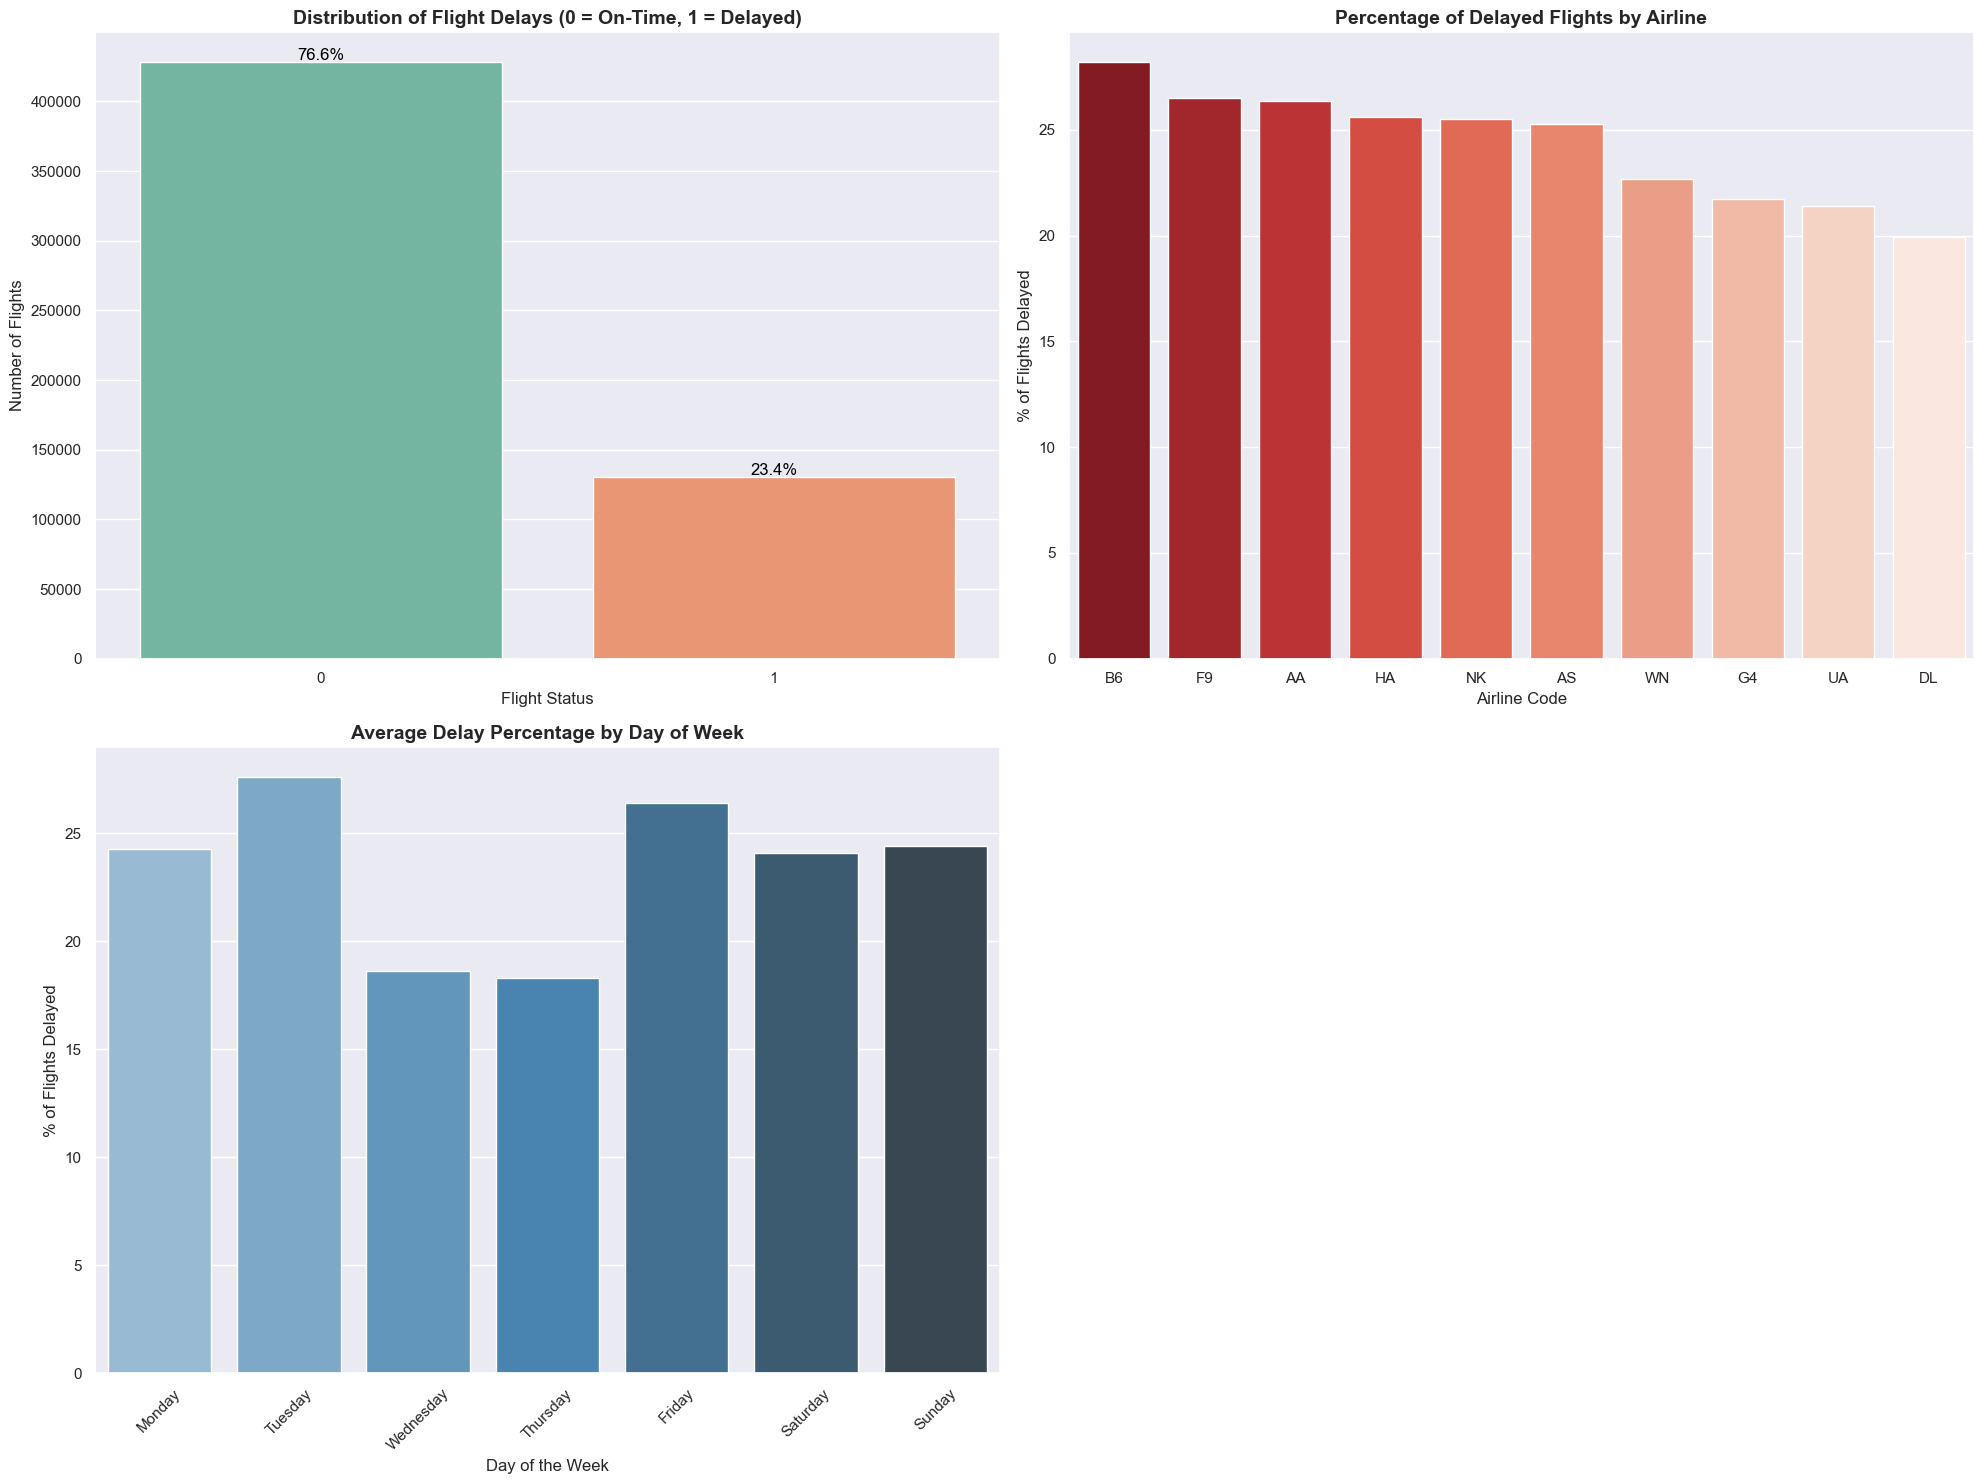

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# 1. Feature Extraction (Date se din aur mahina nikalte hain)
# FlightDate ko proper datetime object banate hain
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Month'] = df['FlightDate'].dt.month
df['DayOfWeek'] = df['FlightDate'].dt.dayofweek # 0=Monday, 6=Sunday

# 2. Setup Plotting Environment
plt.figure(figsize=(20, 15))
sns.set_theme(style="darkgrid")

# --- CHART 1: Target Variable Imbalance ---
plt.subplot(2, 2, 1)
ax = sns.countplot(x='IS_DELAYED', data=df, palette='Set2')
plt.title('Distribution of Flight Delays (0 = On-Time, 1 = Delayed)', fontsize=14, fontweight='bold')
plt.xlabel('Flight Status')
plt.ylabel('Number of Flights')
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

# --- CHART 2: Which Airline is the most delayed? ---
plt.subplot(2, 2, 2)
# Calculate percentage of delays per airline
airline_delay = df.groupby('Marketing_Airline_Network')['IS_DELAYED'].mean() * 100
airline_delay = airline_delay.sort_values(ascending=False).reset_index()

sns.barplot(x='Marketing_Airline_Network', y='IS_DELAYED', data=airline_delay, palette='Reds_r')
plt.title('Percentage of Delayed Flights by Airline', fontsize=14, fontweight='bold')
plt.xlabel('Airline Code')
plt.ylabel('% of Flights Delayed')

# --- CHART 3: Delays by Day of the Week ---
plt.subplot(2, 2, 3)
day_delay = df.groupby('DayOfWeek')['IS_DELAYED'].mean() * 100
day_delay.index = [calendar.day_name[i] for i in day_delay.index] # Convert 0-6 to Monday-Sunday

sns.barplot(x=day_delay.index, y=day_delay.values, palette='Blues_d')
plt.title('Average Delay Percentage by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('% of Flights Delayed')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

# 1. Feature Selection (Jo data flight udne se pehle available hota hai)
# Dhyan rahe IS_DELAYED hamara target hai
important_cols = [
    'Month', 'DayOfWeek', 'Marketing_Airline_Network', 
    'Origin', 'Dest', 'CRSDepTime', 'Distance', 'IS_DELAYED'
]

# Jo columns dataset mein actually hain, bas unko select karte hain
existing_cols = [col for col in important_cols if col in df.columns]
final_df = df[existing_cols].copy()

# 2. Extracting 'Hour' from Scheduled Departure Time (CRSDepTime)
# CRSDepTime usually 1530 (3:30 PM) format mein hota hai. Hum divide by 100 karke sirf '15' nikalenge.
if 'CRSDepTime' in final_df.columns:
    final_df['DepHour'] = final_df['CRSDepTime'] // 100
    final_df = final_df.drop(columns=['CRSDepTime']) # Puraana column uda do

# 3. Label Encoding (Convert Text to Numbers)
le_dict = {} # Future (Streamlit) mein kaam aayega categories yaad rakhne ke liye
categorical_cols = ['Marketing_Airline_Network', 'Origin', 'Dest']

for col in categorical_cols:
    if col in final_df.columns:
        le = LabelEncoder()
        final_df[col] = le.fit_transform(final_df[col].astype(str))
        le_dict[col] = le # Save encoder

# 4. Drop any remaining null rows just to be 100% safe
final_df = final_df.dropna()

print(f"✅ Feature Engineering Complete! Columns left: {final_df.shape[1]}")
display(final_df.head())

✅ Feature Engineering Complete! Columns left: 8


,Month,DayOfWeek,Marketing_Airline_Network,Origin,Dest,Distance,IS_DELAYED,DepHour
0,1,6,8,215,112,209.0,1,17
1,1,6,8,158,112,212.0,1,8
2,1,6,8,112,215,209.0,1,15
3,1,6,8,319,238,258.0,1,6
4,1,6,8,319,158,696.0,1,13


Preparing Data for Training...
Training the XGBoost Model... (Isme thoda time lag sakta hai ⏳)
✅ Model Trained Successfully!

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.84      0.60      0.70     85647
           1       0.32      0.61      0.42     26096

    accuracy                           0.61    111743
   macro avg       0.58      0.61      0.56    111743
weighted avg       0.72      0.61      0.64    111743


💾 Model & Encoders saved to disk for Streamlit Deployment!


<Figure size 1000x600 with 0 Axes>

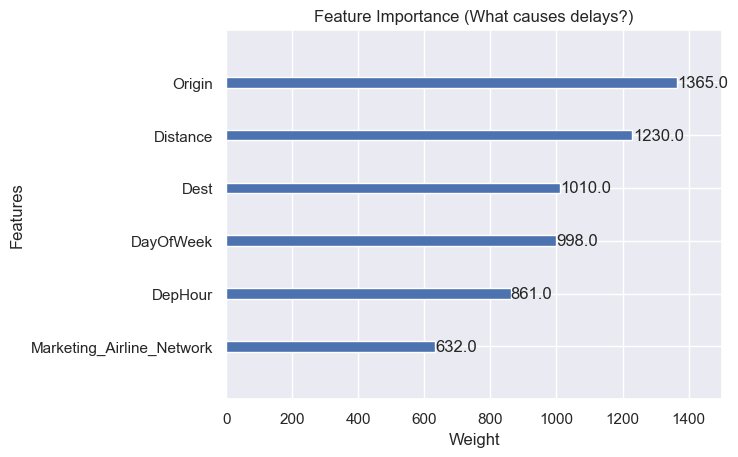

In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

print("Preparing Data for Training...")

# 1. Features (X) aur Target (y) ko alag karna
X = final_df.drop('IS_DELAYED', axis=1)
y = final_df['IS_DELAYED']

# 2. Train-Test Split (80% data seekhne ke liye, 20% test karne ke liye)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Handle Imbalance (On-time / Delayed ka ratio nikal rahe hain)
imbalance_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# 4. Initialize XGBoost Model
print("Training the XGBoost Model... (Isme thoda time lag sakta hai ⏳)")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,           # Number of trees
    learning_rate=0.1,          # Seekhne ki speed
    max_depth=6,                # Tree ki gehraai
    scale_pos_weight=imbalance_ratio, # Class imbalance fix
    random_state=42,
    n_jobs=-1                   # PC ke saare cores use karo fast training ke liye
)

# 5. Fit the model
xgb_model.fit(X_train, y_train)
print("✅ Model Trained Successfully!\n")

# 6. Predictions aur Evaluation
y_pred = xgb_model.predict(X_test)
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# 7. Deployment ke liye Model aur Encoders ko save karna (Bahut Important!)
joblib.dump(xgb_model, 'flight_delay_xgboost_model.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')
print("\n💾 Model & Encoders saved to disk for Streamlit Deployment!")

# --- VISUALIZATION: Feature Importance (Kaunsa column sabse zyada kaam aaya?) ---
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10, 
                    title='Feature Importance (What causes delays?)', xlabel='Weight')
plt.show()

In [ ]:
#MODEL TRAINED SUCCESSFULLY
